In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import bacco

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [9]:
npoints=70
ndim = 6
seed = 1997

In [11]:
bounds = np.array([
                   [0.9, 14.4],                      # WindEnergyIn1e51erg 
                   [3.7,14.8],                       # VariableWindVelFactor
                   [1.135,4.54],                     # MaxSfrTimescale
                   [np.log10(0.001), np.log10(0.1)], # Quasar Threshold 
                   [0.05, 0.2],                      # BlackHoleFeedbackFactor
                   [np.log10(0.001), np.log10(2)],   # RadioFeedbackFactor
                ])
print("Creating LH with {0} points in {1} dimensions".format(npoints, ndim))
_cpars = bacco.utils.latinhypercube( ndim, npoints, spread=False, seed=seed)
cpars = bounds[:,0] + _cpars * (bounds[:,1] - bounds[:,0])
#dd.io.save( "cpars_{0}_{1}.h5".format(npoints, seed), {'cpars':cpars})

Creating LH with 70 points in 6 dimensions


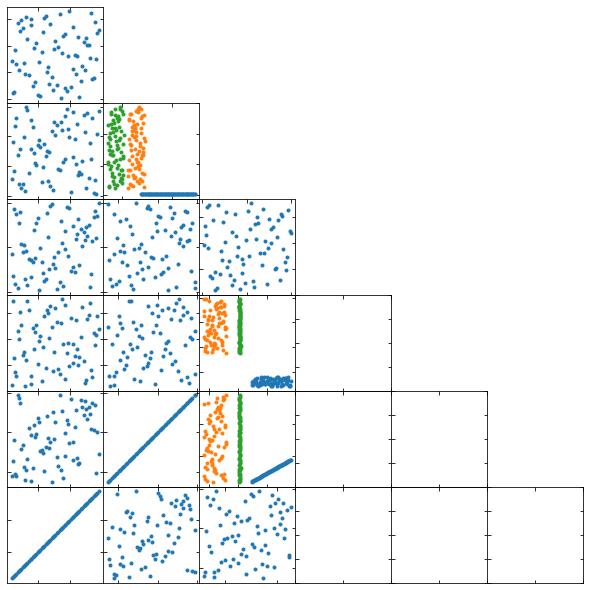

In [44]:
import matplotlib.pyplot as plt

# Create a figure
fig = plt.figure(figsize=(8, 8))

# Define the positions for the subplots
# Positions are normalized with respect to figure size
positions = []
N = 6
for i in range(N):
    for j in range(N-i):
        positions.append([i*1/N, j*1/N, 1/N, 1/N])

ax = []
for i in range(int(N*(N+1)/2)):
    ax.append(fig.add_axes(positions[i]))
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])

for i in range(N):
    for j in range(N-i):
        ax[i*(N-i+1)+j].plot(cpars[:,i], cpars[:,j], ls='', marker='o', ms=3)


# Adjust layout
plt.show()


In [4]:
# catalog name
catalog = '/scratch/fgmaion/CAMELS/1P/1P_0/groups_090.hdf5'

# value of the scale factor
scale_factor = 1.0

# open the catalogue
f = h5py.File(catalog, 'r')

boxsize = f['Header'].attrs['BoxSize']/1e3
hfac = f['Header'].attrs['HubbleParam']
print(f.keys())
print(f['Subhalo'].keys())
print(f['Parameters'].attrs['Omega0'])
print(f['Parameters'].attrs['WindEnergyIn1e51erg'])
print(f['Parameters'].attrs['VariableWindVelFactor'])
print(f['Parameters'].attrs['RadioFeedbackFactor'])
print(f['Parameters'].attrs['RadioFeedbackReiorientationFactor'])

# read the positions, velocities and masses of the FoF halos
pos_h  = f['Group/GroupPos'][:]/1e3           #positions in Mpc/h
vel_h  = f['Group/GroupVel'][:]/scale_factor  #velocities in km/s
mass_h = f['Group/GroupMass'][:]*1e10         #masses in Msun/h

# read the positions, black hole masses and stellar masses of the subhalos/galaxies
pos_g  = f['Subhalo/SubhaloMass'][:]/1e3        #positions in Mpc/h
BH_g   = f['Subhalo/SubhaloBHMass'][:]*1e10     #black-hole masses in Msun/h
M_star = f['Subhalo/SubhaloMassType'][:,4]*1e10 #stellar masses in Msun/h

# close file
f.close()

<KeysViewHDF5 ['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']>
<KeysViewHDF5 ['SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'SubhaloGasMetallicitySfr', 'SubhaloGasMetallicitySfrWeighted', 'SubhaloGrNr', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadType', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloMassInMaxRad', 'SubhaloMassInMaxRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloSFR', 'SubhaloSFRinHalfRad', 'SubhaloSFRinMaxRad', 'SubhaloSFRinRad', 'SubhaloSpin', 'SubhaloStarMetalFractions', 'SubhaloStarMetalFractionsHalfRad', 'SubhaloStarMetalF

In [5]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = np.log10( 10**GAMA[:,0] / 0.7**2 )
GAMA_corr[:,1] = np.log10( 10**GAMA[:,1] * 0.7**3 )

# Transforming the errors is a bit more involved
xn = 10**GAMA[:,1] * ( 1 - 10**(-GAMA[:,2]) )
xp = 10**GAMA[:,1] * ( 10**(GAMA[:,2]) - 1 )

GAMA_corr[:,2] = GAMA[:,1] - np.log10( 10**GAMA[:,1] - xn  )
GAMA_corr[:,3] = np.log10( 10**GAMA[:,1] + xp  ) - GAMA[:,1]

In [6]:
import matplotlib

In [7]:
smf = {}
index = ['n2', 'n1', '0', '1', '2']

smf['gal_wind'] = {}
smf['rad_fb'] = {}
smf['wind_vel'] = {}
smf['reor_fac'] = {}
for i in range(5):
    smf['gal_wind'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=3, nbins=20)
    smf['rad_fb'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=4, nbins=20)
    smf['wind_vel'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=5, nbins=20)
    smf['reor_fac'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=6, nbins=20)

/lscratch/fgmaion/MTNG-resims/src/utils.py:600: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}


/tmp/ipykernel_107521/737250541.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/737250541.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/737250541.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/737250541.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/737250541.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1

Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

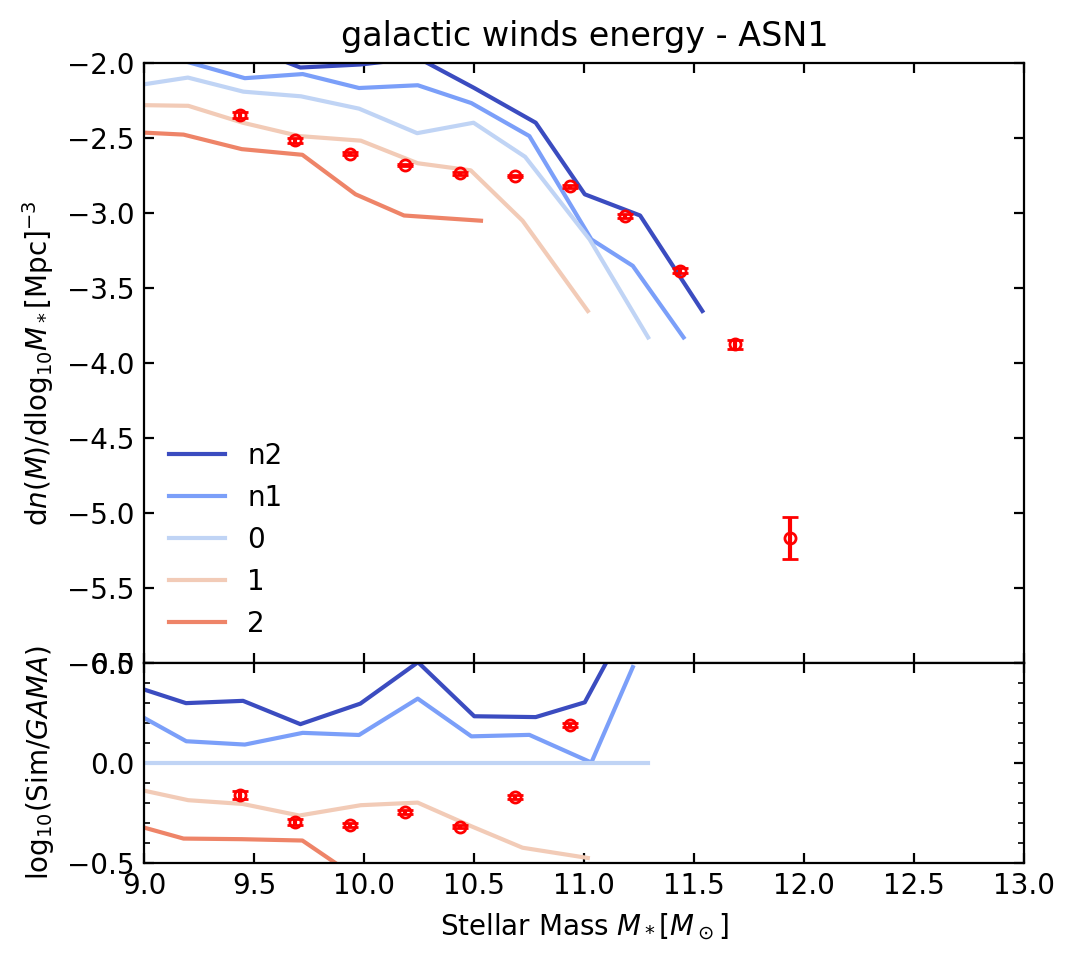

In [8]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('galactic winds energy - ASN1')

cmap = matplotlib.cm.get_cmap('coolwarm')
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=cmap(i/5), label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf'])-np.log10(smf['gal_wind']['0']['smf']), color=cmap(i/5))
#    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']) )-GAMA_corr[:,1], color=cmap(i/5))

#ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')
ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1] - np.interp( GAMA_corr[:,0], np.log10(smf['gal_wind']['0']['mstar']), np.log10(smf['gal_wind']['0']['smf']) ), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


/tmp/ipykernel_107521/1217508224.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/1217508224.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/1217508224.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/1217508224.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_107521/1217508224.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.lo

Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

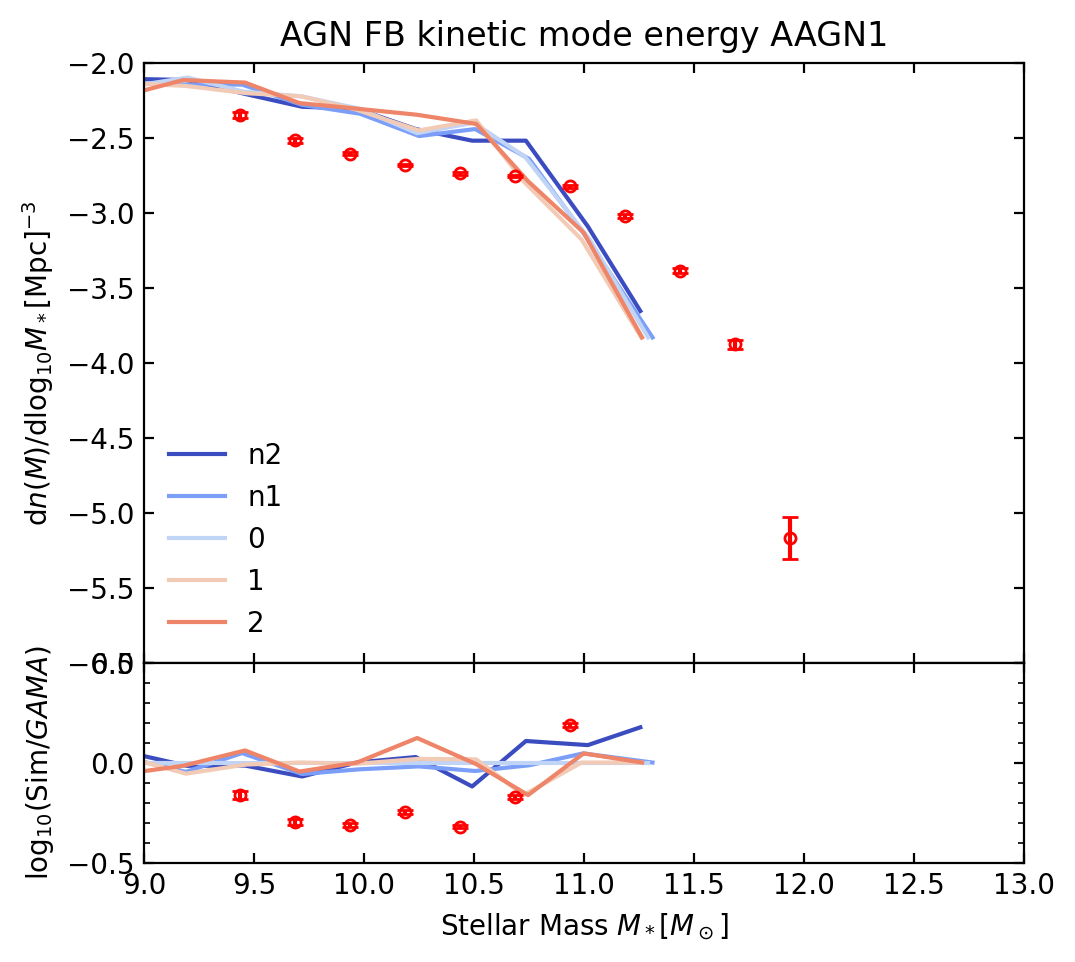

In [9]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('AGN FB kinetic mode energy AAGN1')

cmap = matplotlib.cm.get_cmap('coolwarm')
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=cmap(i/5), label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf'])-np.log10(smf['rad_fb']['0']['smf']), color=cmap(i/5))
#    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']) )-GAMA_corr[:,1], color=cmap(i/5))

#ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')
ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1] - np.interp( GAMA_corr[:,0], np.log10(smf['rad_fb']['0']['mstar']), np.log10(smf['rad_fb']['0']['smf']) ), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


/tmp/ipykernel_94954/581928256.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/581928256.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/581928256.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/581928256.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/581928256.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot

Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

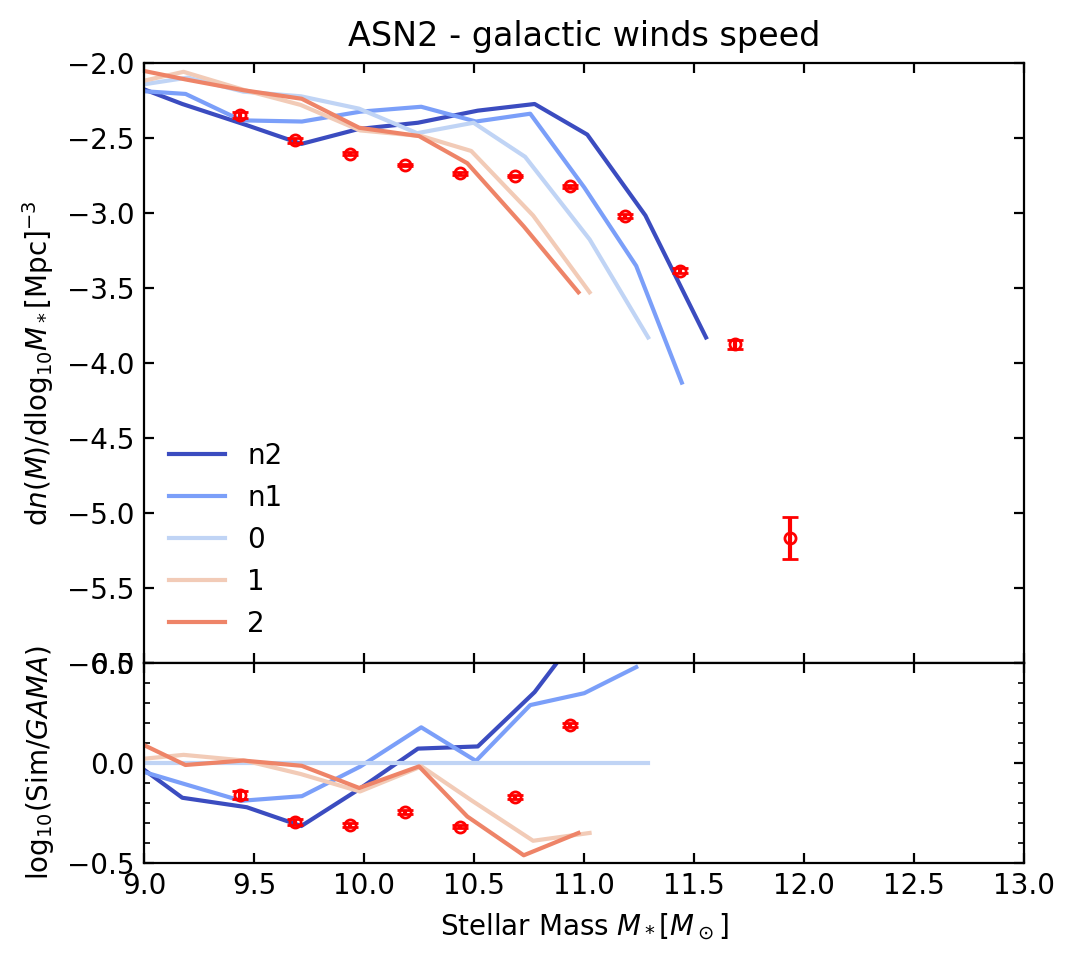

In [10]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('ASN2 - galactic winds speed')

cmap = matplotlib.cm.get_cmap('coolwarm')
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=cmap(i/5), label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf'])-np.log10(smf['wind_vel']['0']['smf']), color=cmap(i/5))
#    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']) )-GAMA_corr[:,1], color=cmap(i/5))

#ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')
ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1] - np.interp( GAMA_corr[:,0], np.log10(smf['wind_vel']['0']['mstar']), np.log10(smf['wind_vel']['0']['smf']) ), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')

/tmp/ipykernel_94954/4260360493.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/4260360493.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/4260360493.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/4260360493.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/4260360493.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1

Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

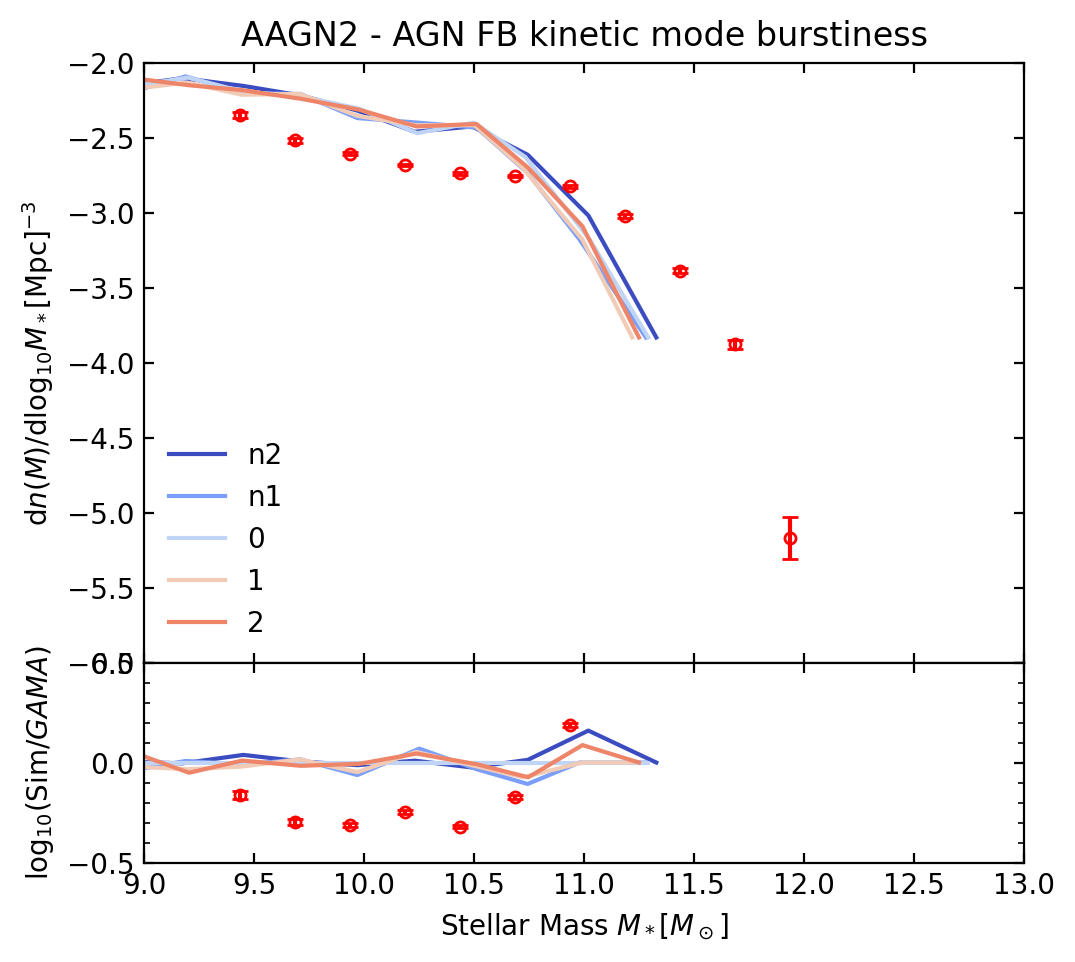

In [11]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('AAGN2 - AGN FB kinetic mode burstiness')

cmap = matplotlib.cm.get_cmap('coolwarm')
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=cmap(i/5), label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf'])-np.log10(smf['reor_fac']['0']['smf']), color=cmap(i/5))
#    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']) )-GAMA_corr[:,1], color=cmap(i/5))

#ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')
ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1] - np.interp( GAMA_corr[:,0], np.log10(smf['reor_fac']['0']['mstar']), np.log10(smf['reor_fac']['0']['smf']) ), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')

### Make plots for all others

In [12]:
filename = "/scratch/fgmaion/CAMELS/1P/info.txt"

data = {}
with open(filename) as f:
    lines = f.readlines()
    for i in range(1,len(lines)):
        lines[i].strip()
        columns = [item.strip() for item in lines[i].split(',')]
        data[i] = {'Name':columns[0], 'AbsMaxDiff':float(columns[1]), 'LogFlag':int(columns[2]), 'FidVal':float(columns[3]), 'MinVal':float(columns[4]), 'MaxVal':float(columns[5]), 'Desc':columns[6]}


/lscratch/fgmaion/MTNG-resims/src/utils.py:429: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}
/tmp/ipykernel_94954/3055118482.py:20: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/3055118482.py:20: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/3055118482.py:20: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_94954/3055118482.py:20: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']), color=cmap(i/5), label=labels[i])
/tmp/ipykernel_949

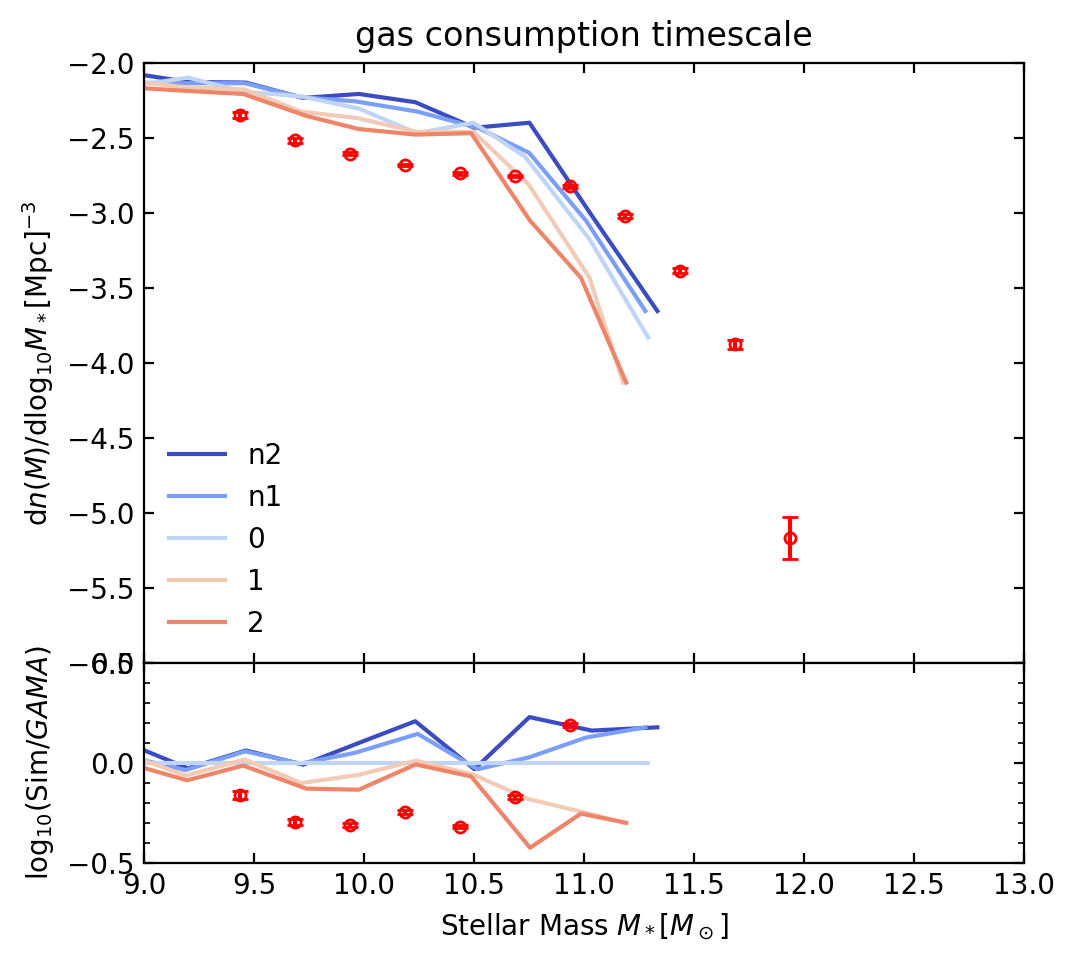

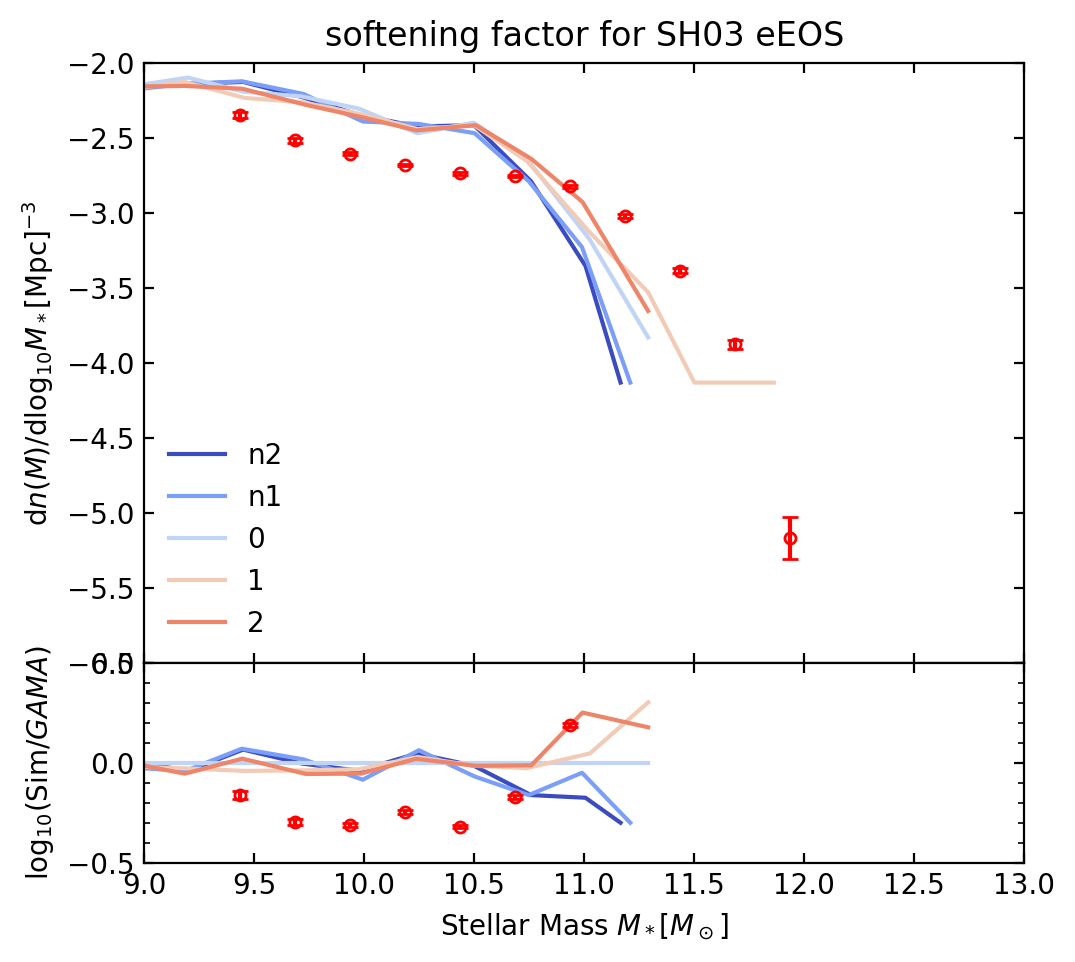

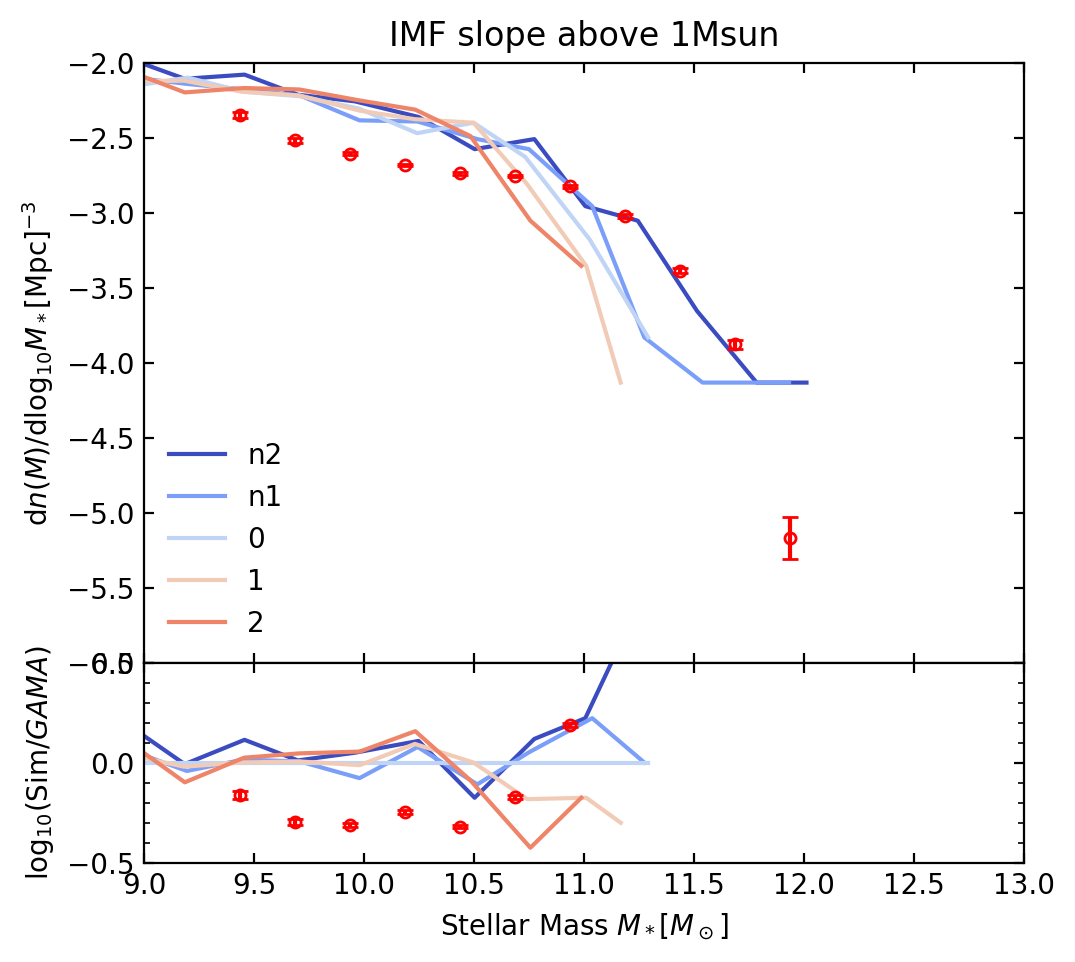

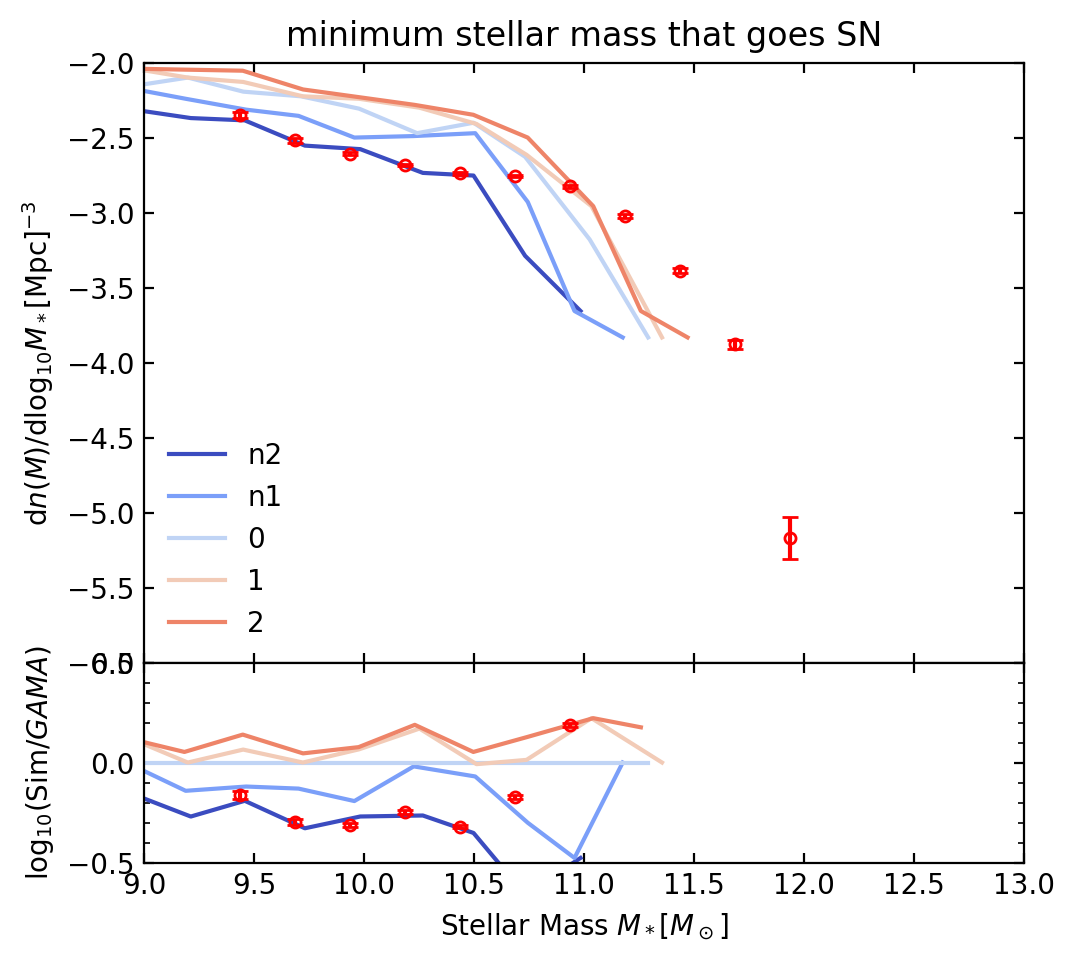

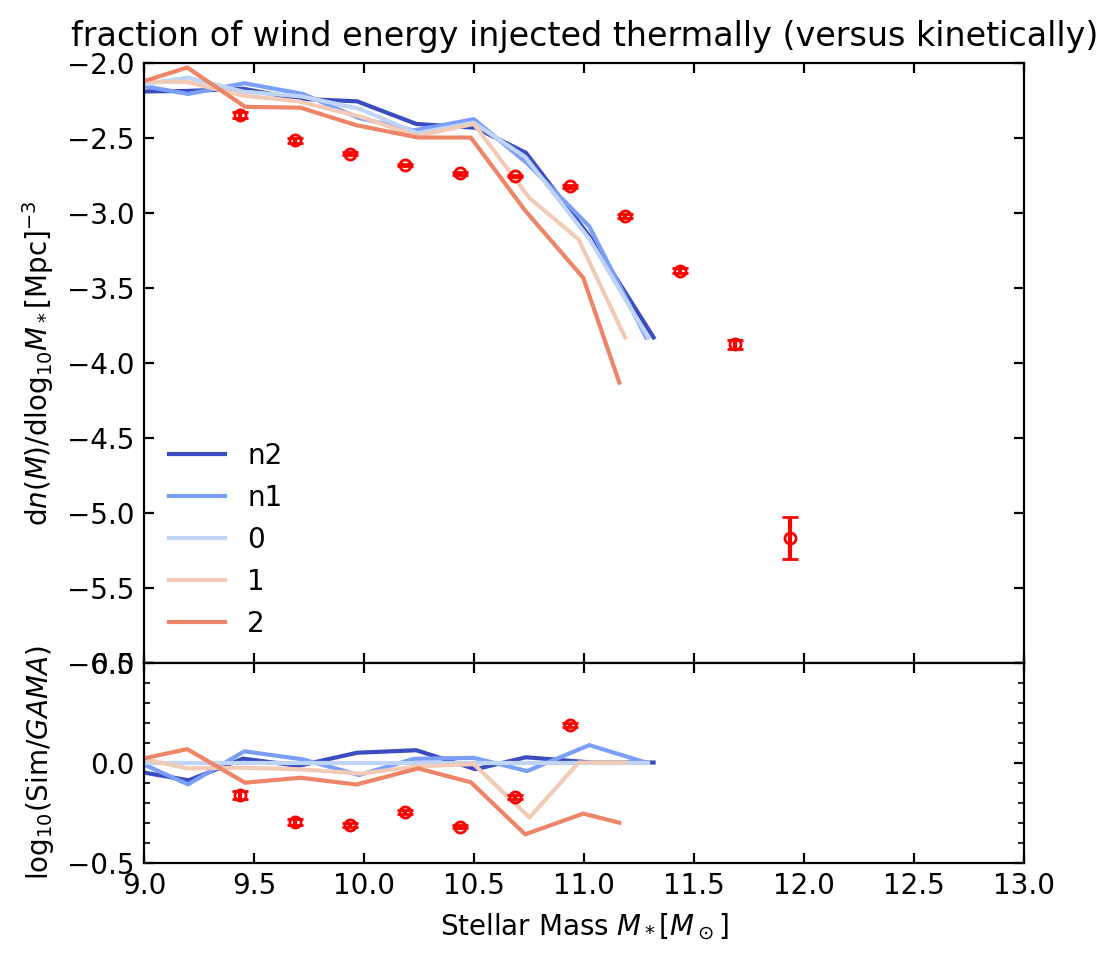

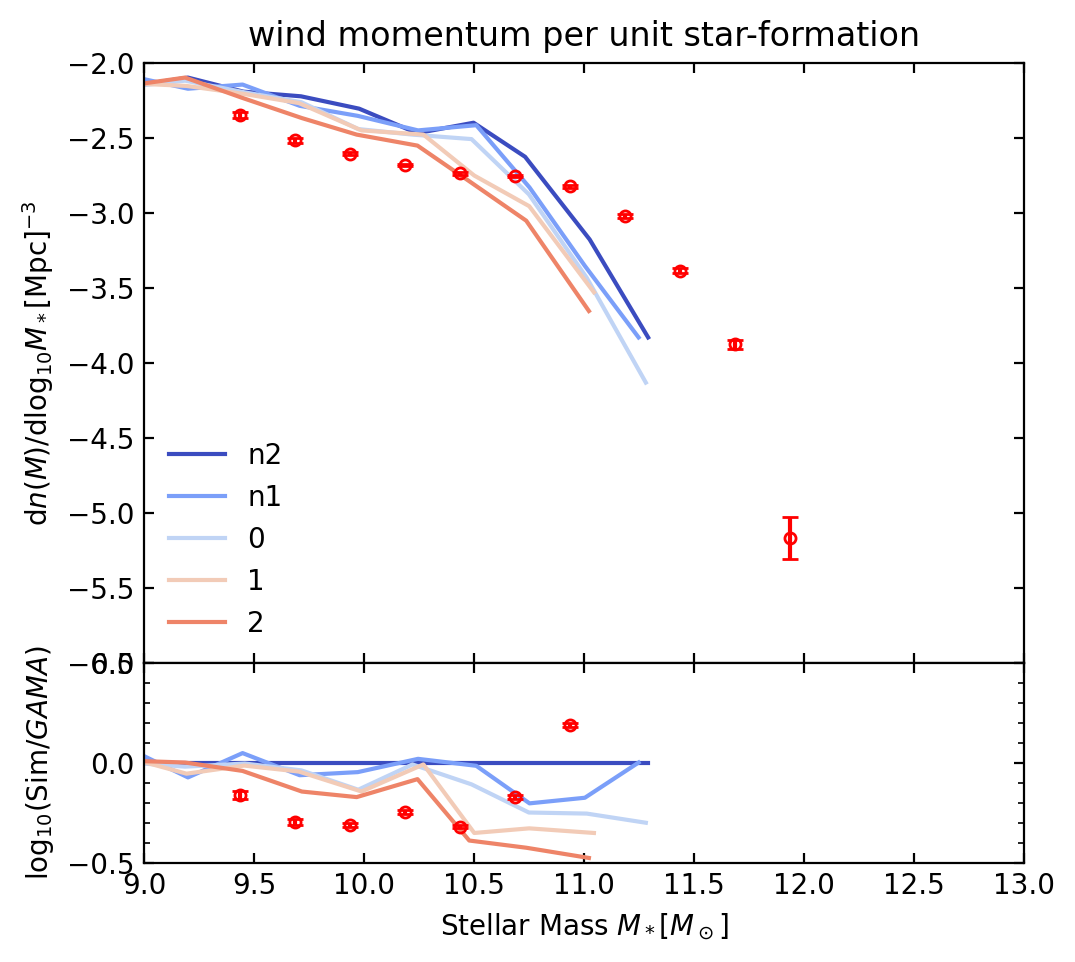

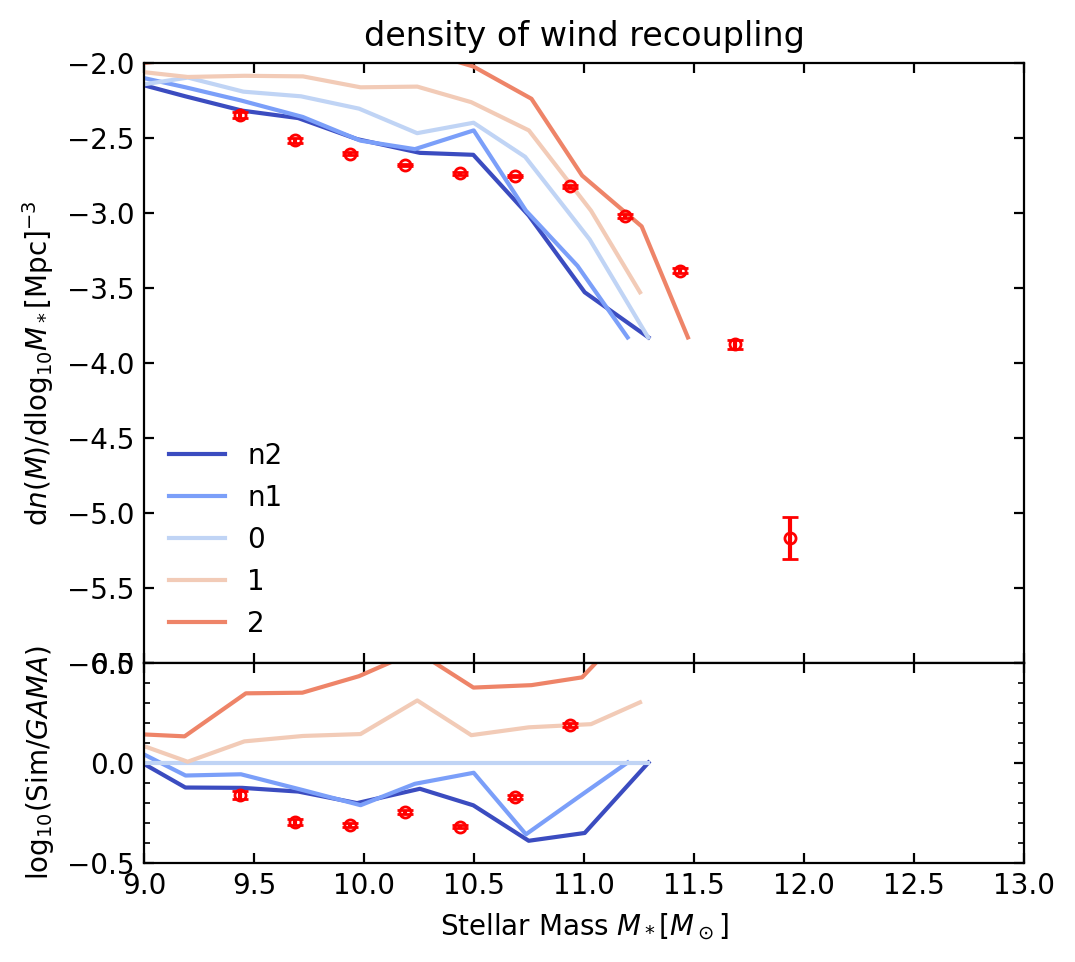

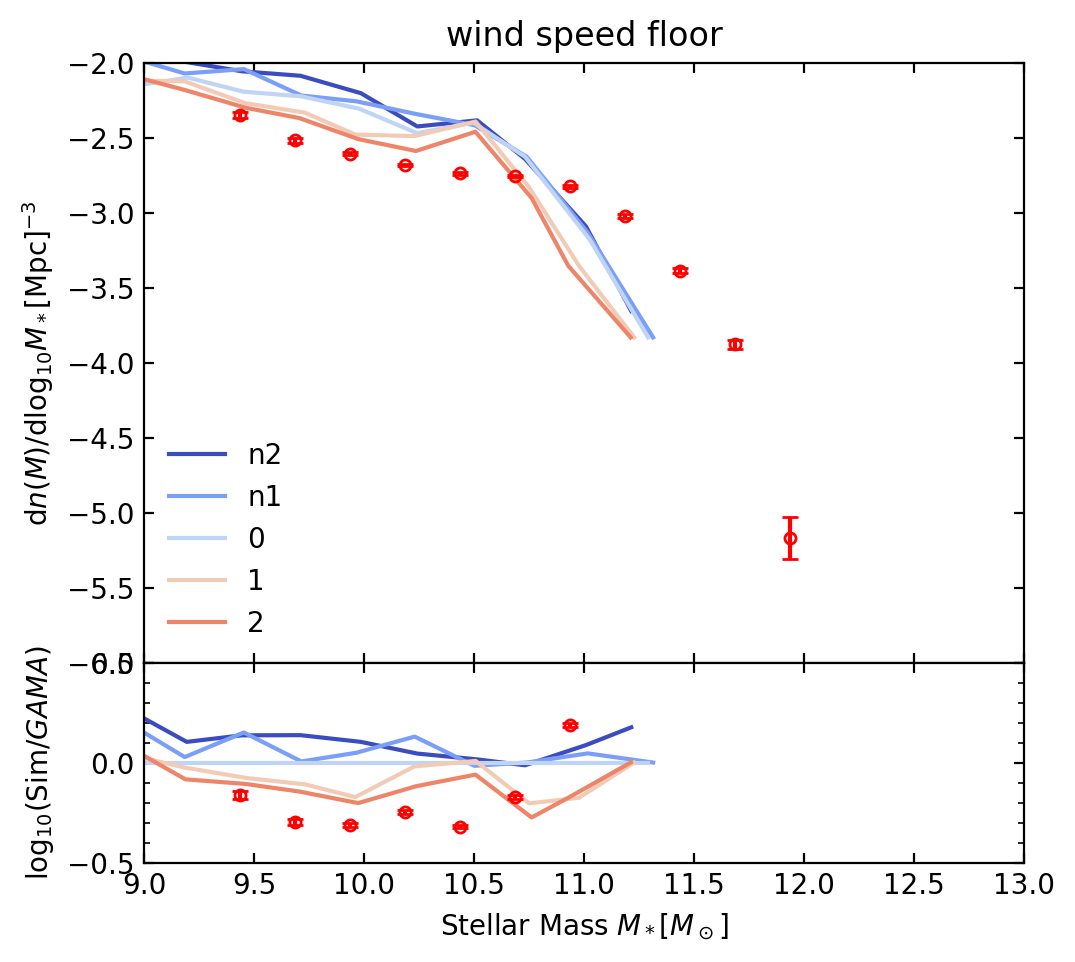

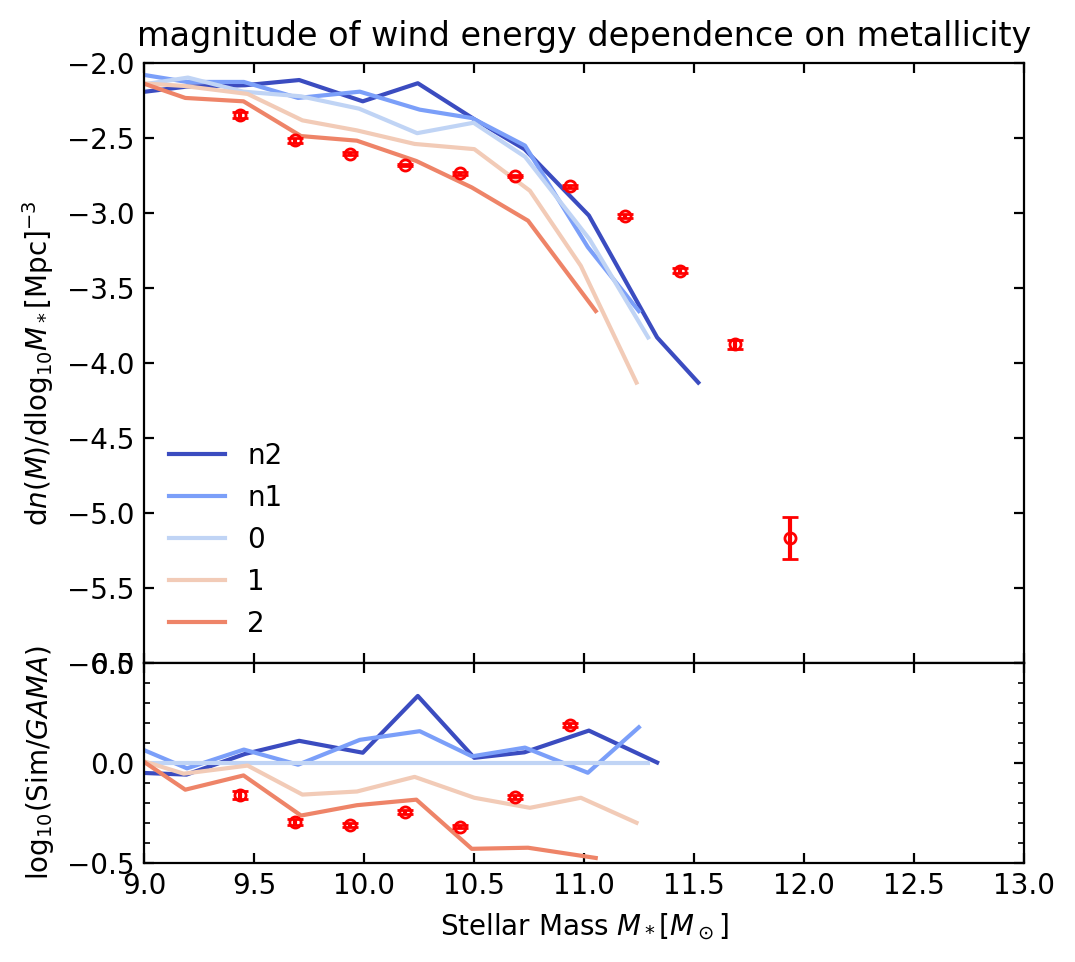

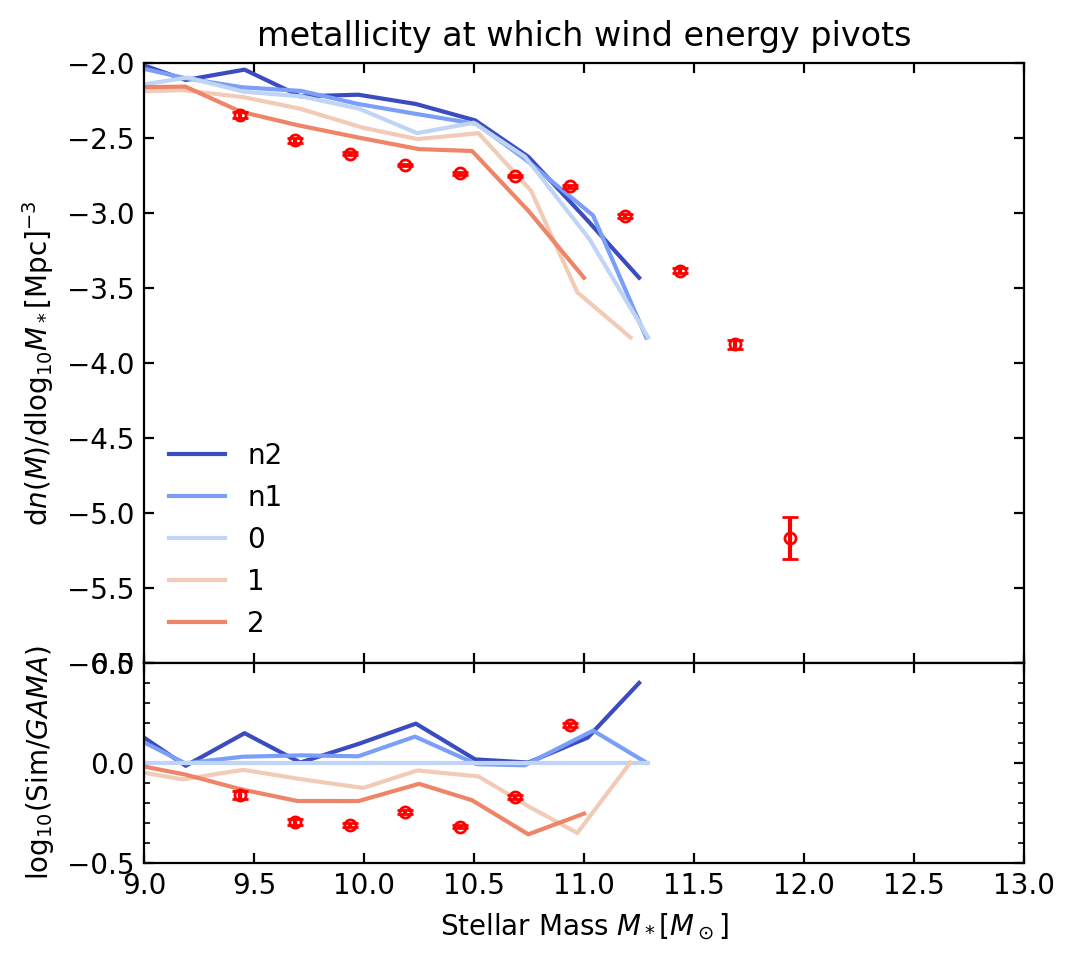

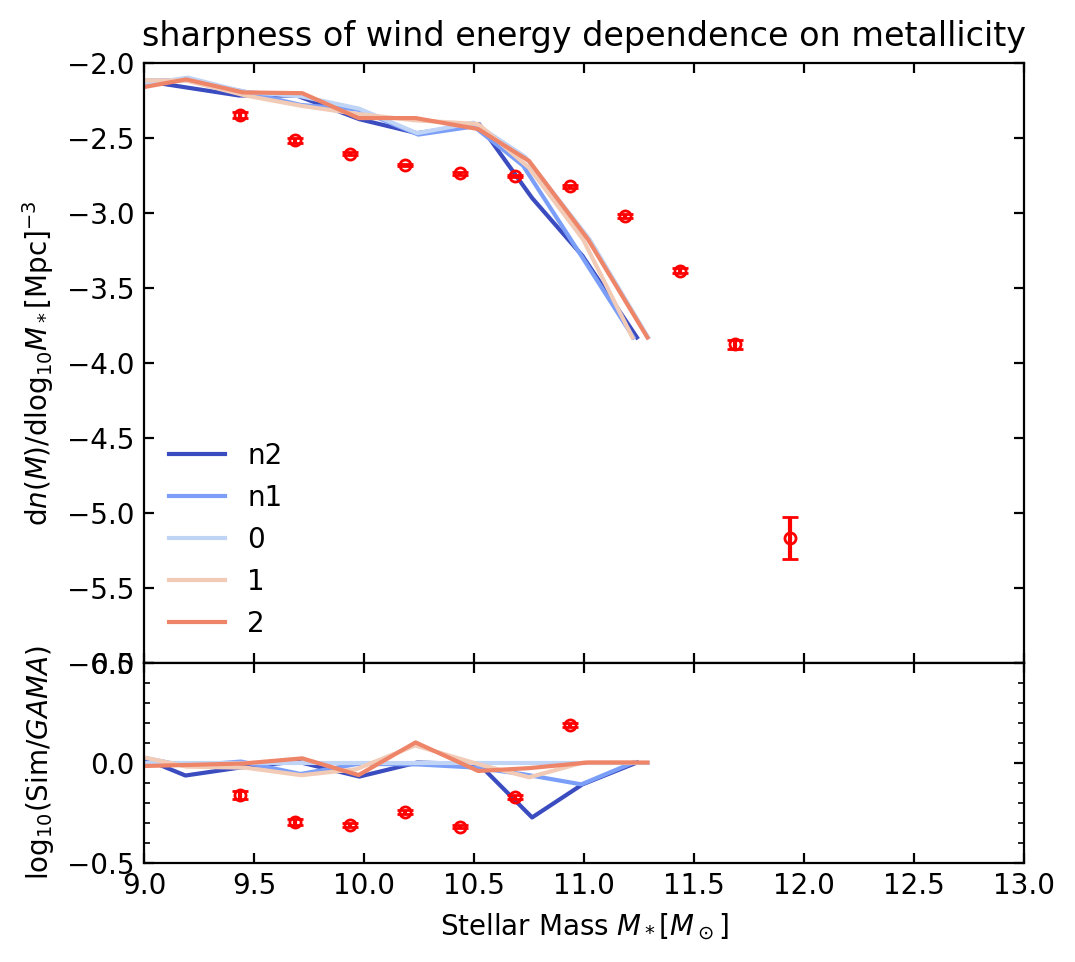

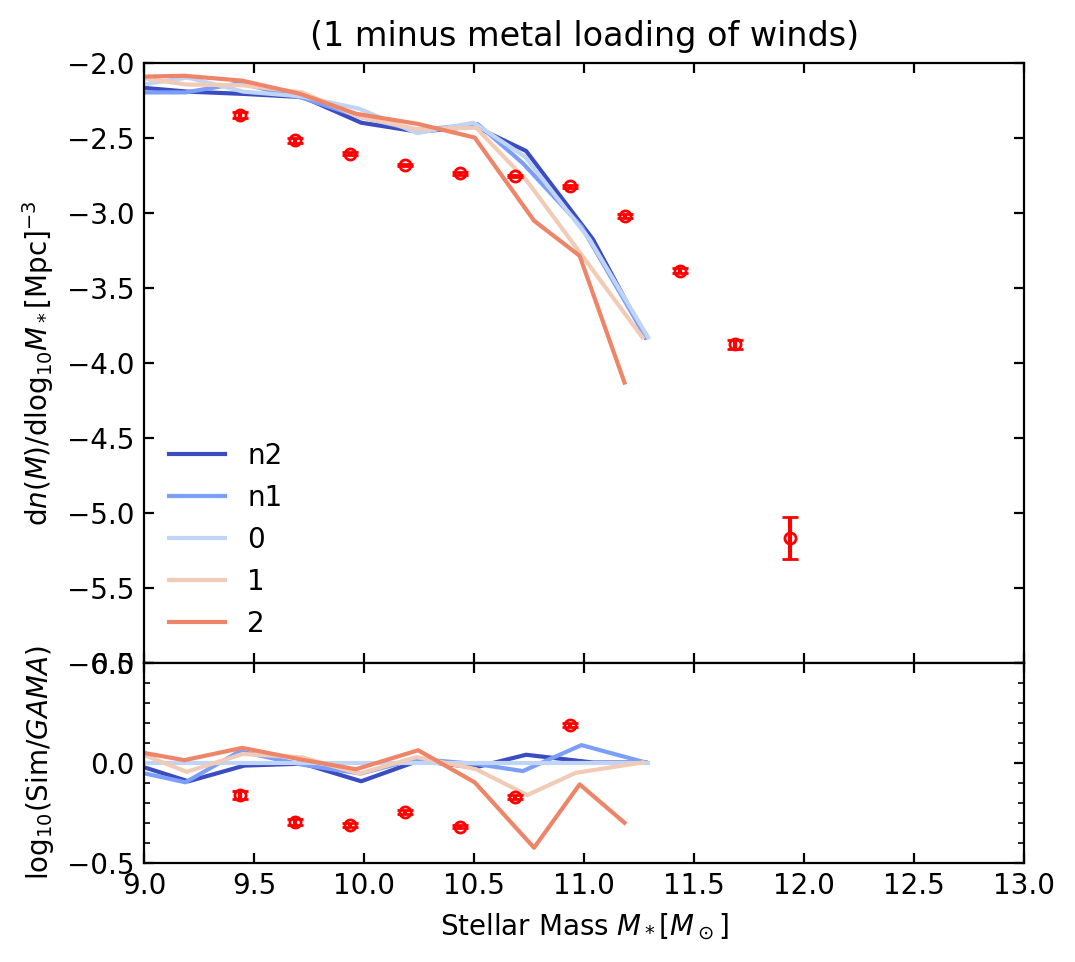

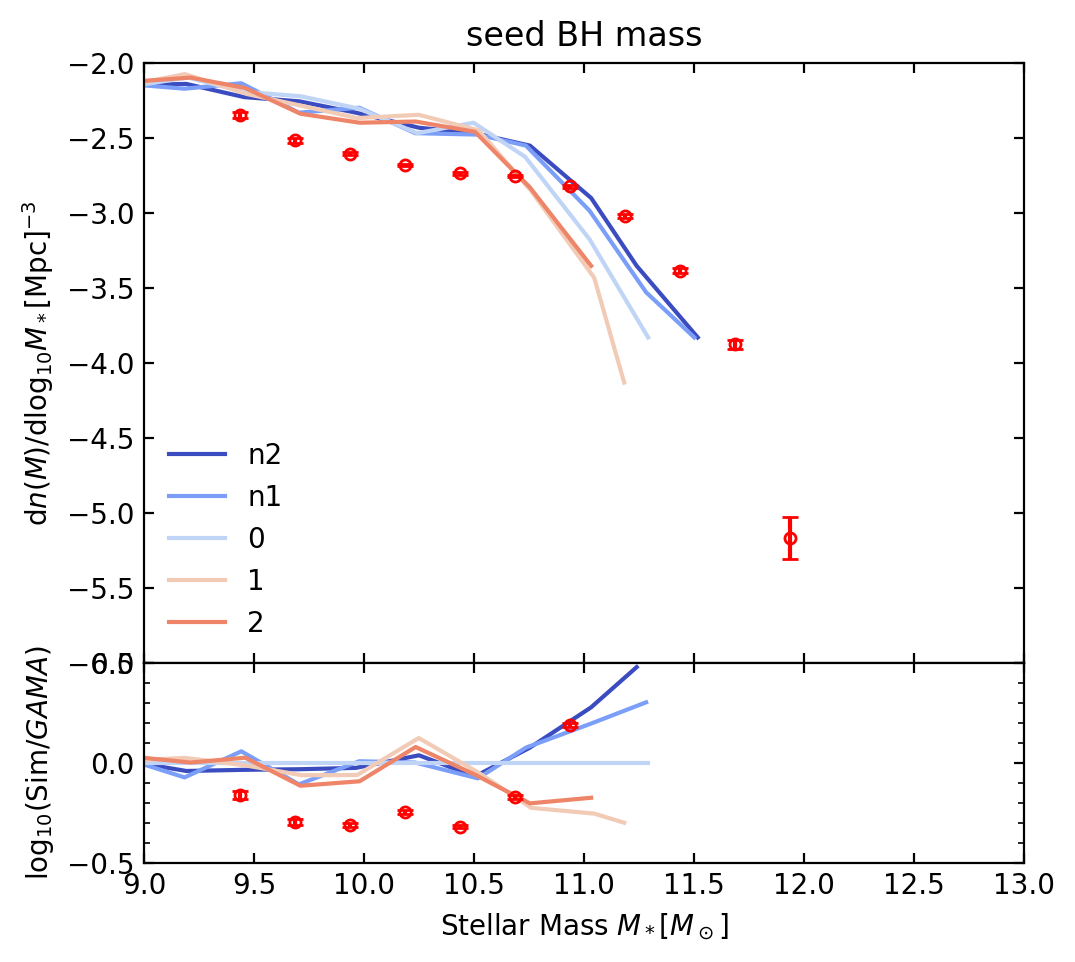

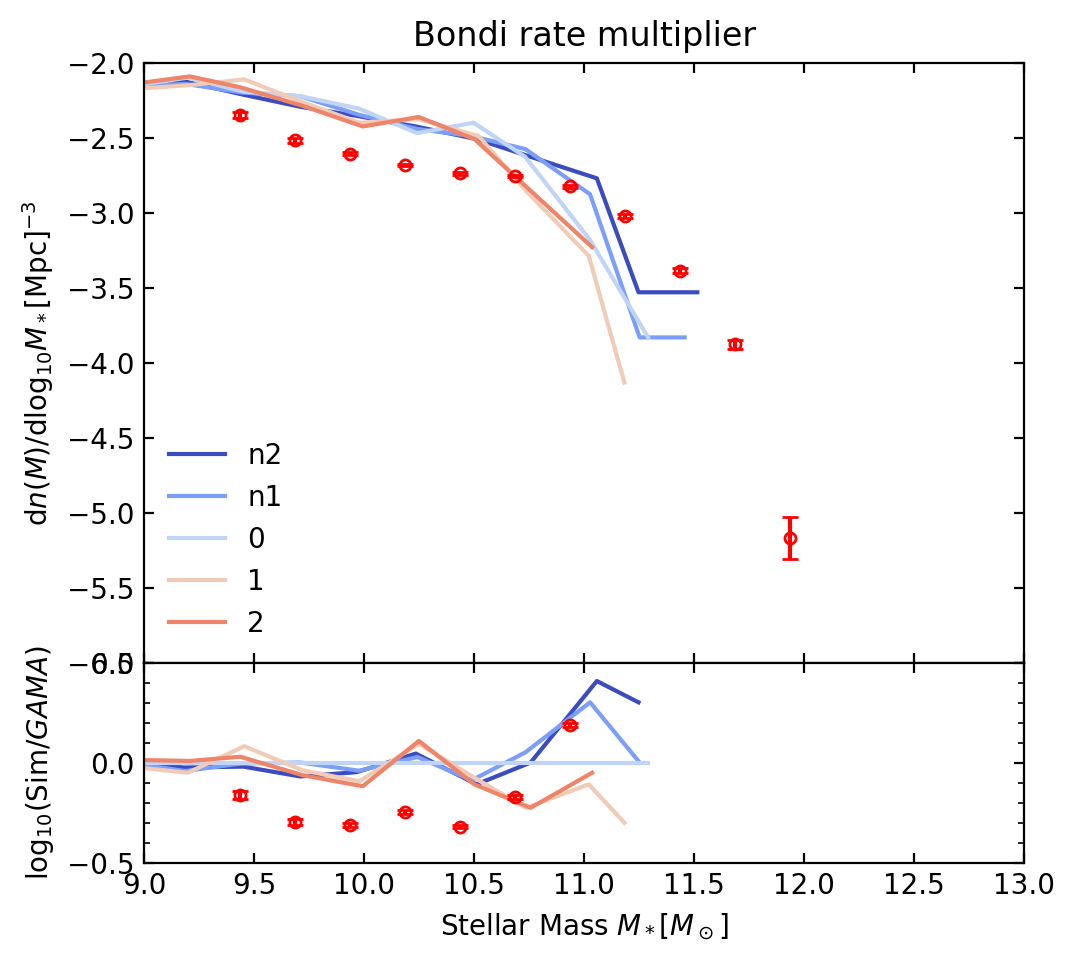

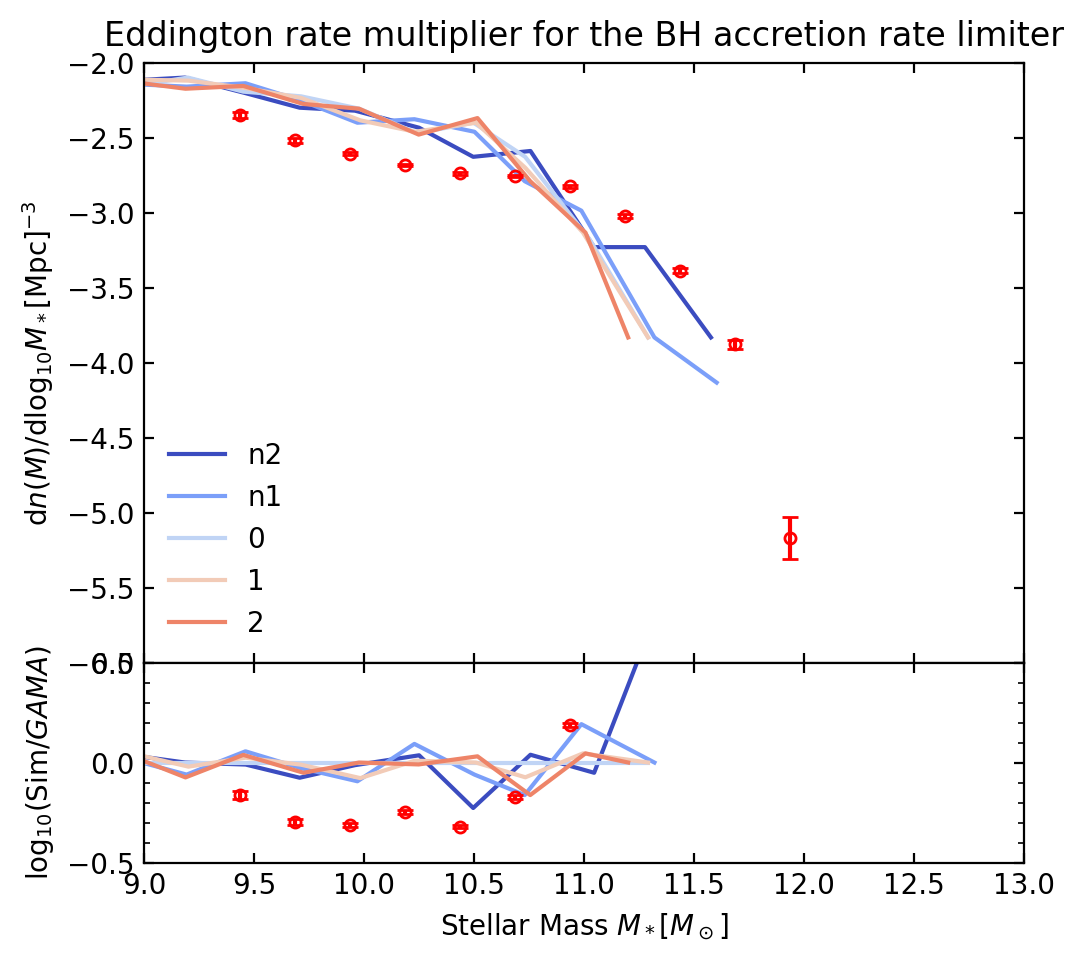

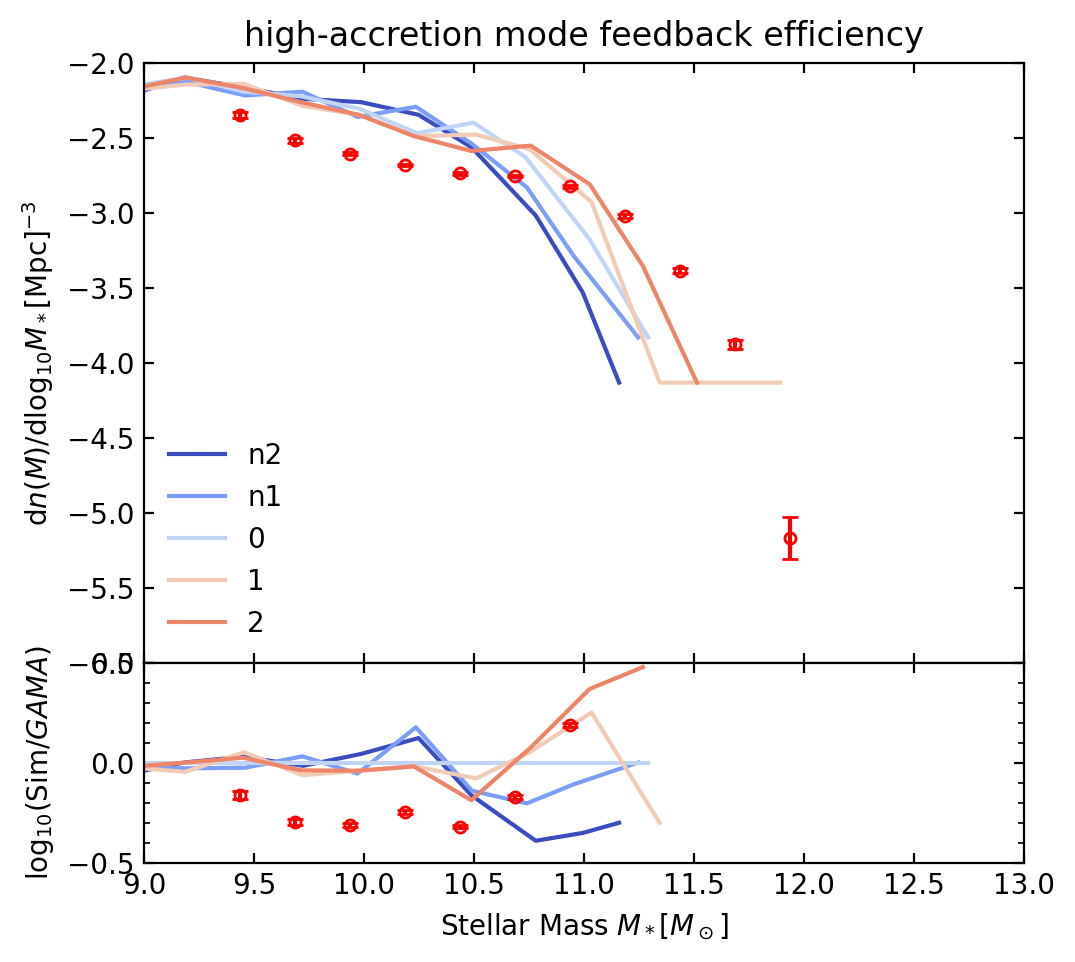

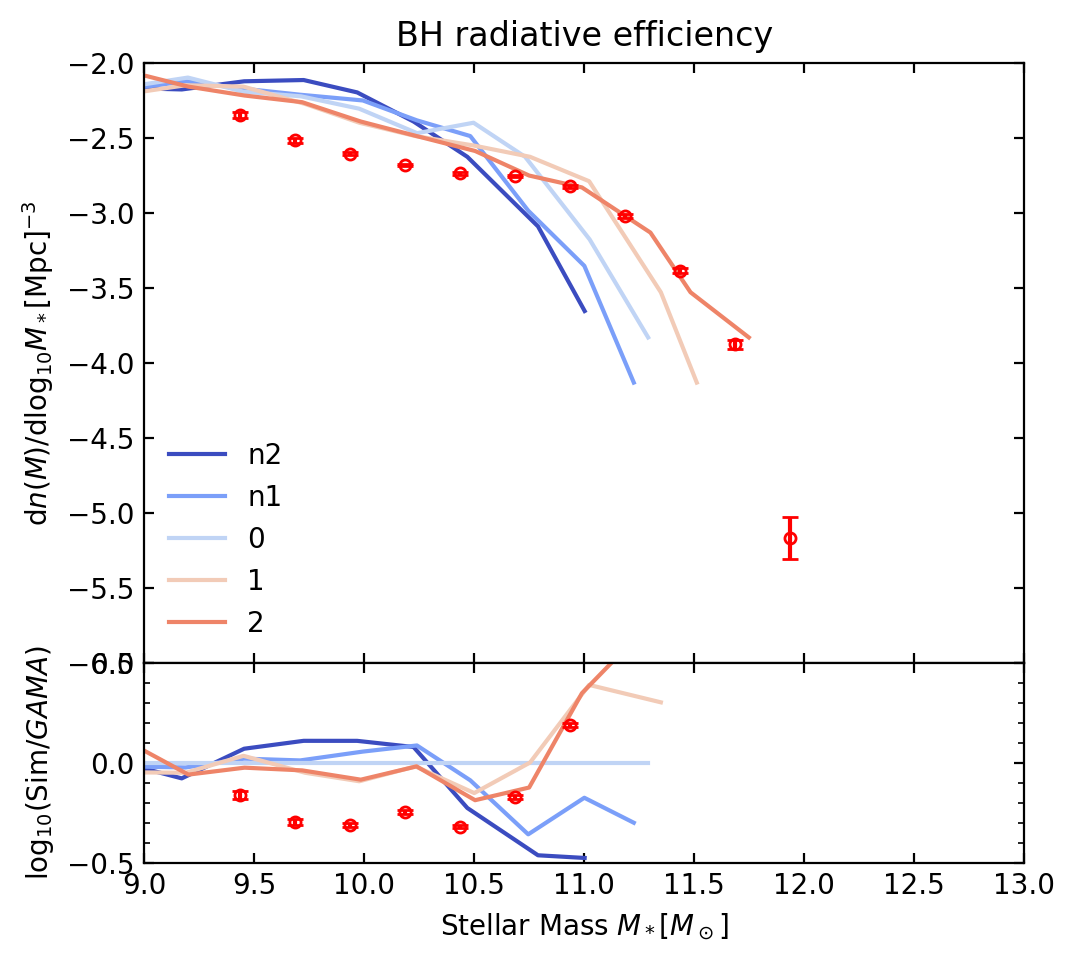

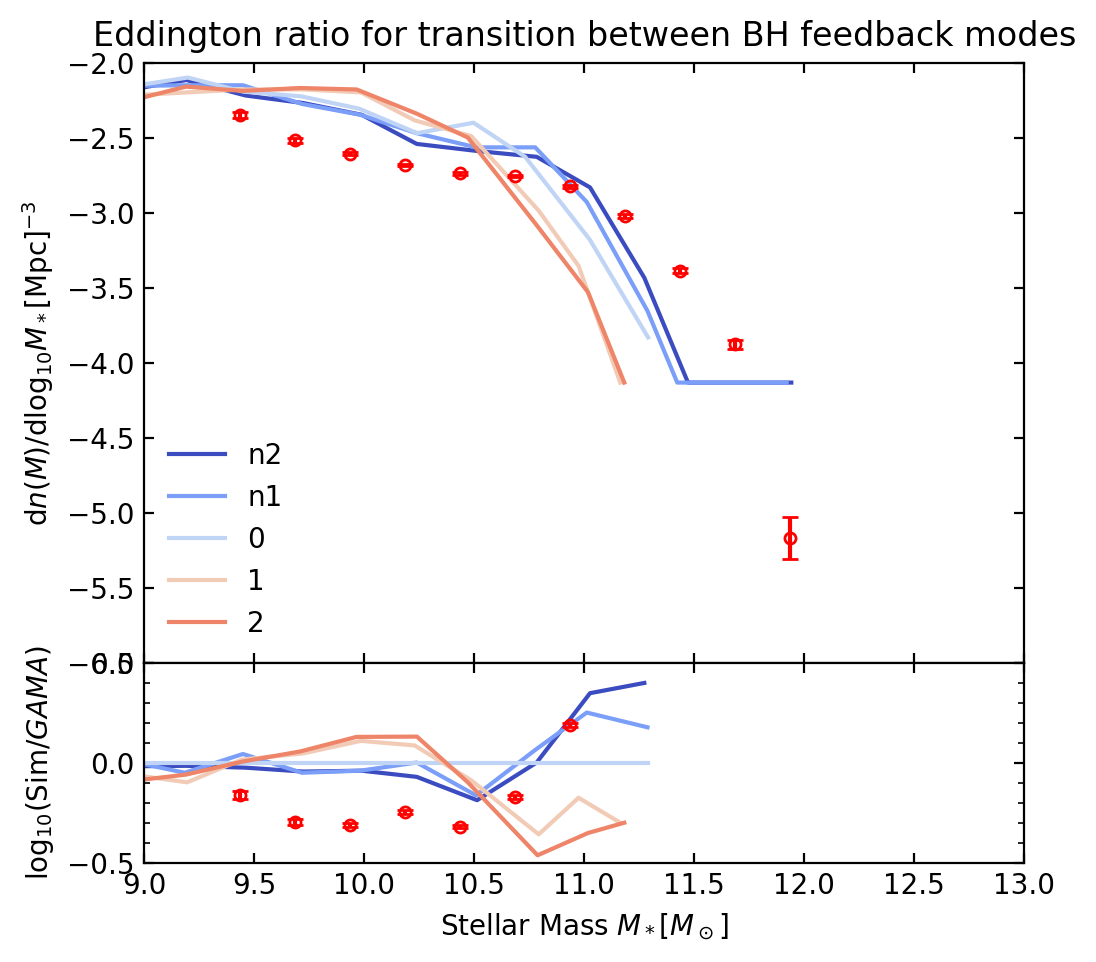

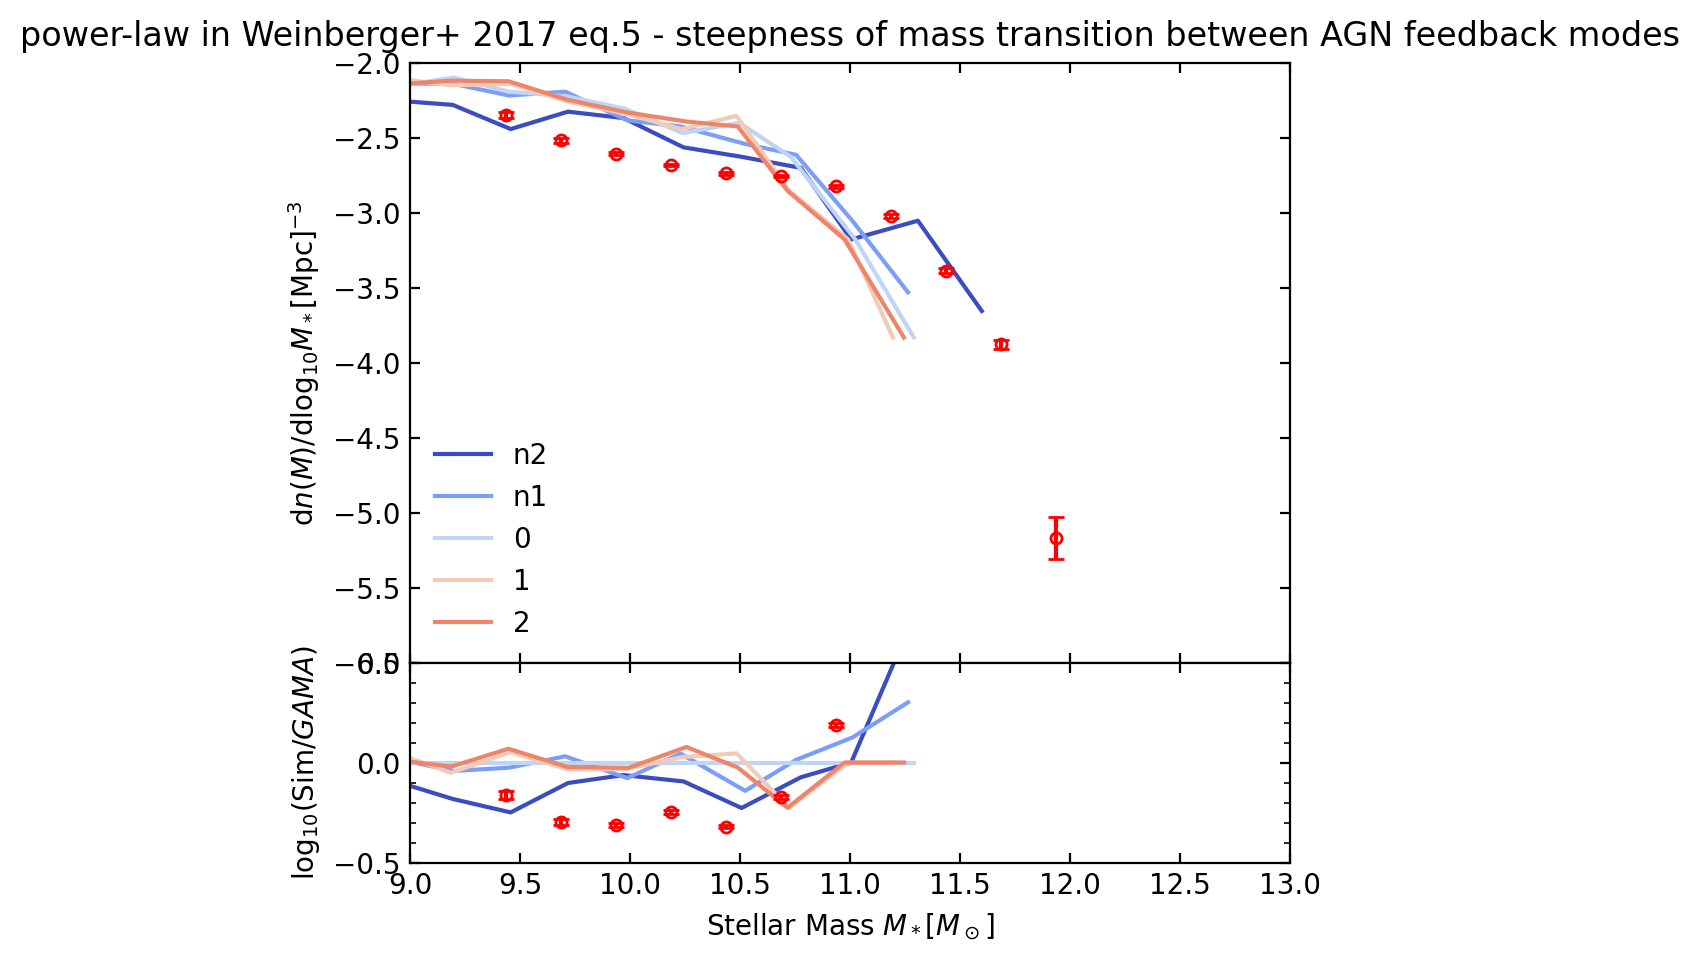

In [13]:
for par in range(10,29):
    smf = {}
    if par!=15:
        index = ['n2', 'n1', '0', '1', '2']
    else:
        index = ['0', '1', '2', '3', '4']
    for i in range(5):
        smf[index[i]] = utils.camels_stellar_mf(index[i], par, nbins=20)

    fig = plt.figure(dpi=200, figsize=(5.5,5))

    ax1=fig.add_axes((.1,.3,.8,.6))

    ax1.set_title(data[par]['Desc'])

    cmap = matplotlib.cm.get_cmap('coolwarm')
    labels=['n2', 'n1', '0', '1', '2']

    for i in range(5):
        ax1.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']), color=cmap(i/5), label=labels[i])

    ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

    ax1.legend(loc='lower left')

    ax1.set_xlim(9, 13) 
    ax1.set_ylim(-6, -2) 

    ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
    ax1.set_xticklabels([])

    ax2=fig.add_axes((.1,.1,.8,.2))        

    for i in range(5):
        ax2.plot(np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf'])-np.log10(smf['0']['smf']), color=cmap(i/5))
        #ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf[index[i]]['mstar']), np.log10(smf[index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

#    ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')
    ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1] - np.interp( GAMA_corr[:,0], np.log10(smf['0']['mstar']), np.log10(smf['0']['smf']) ), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

    ax2.set_xlim(9, 13) 
    ax2.set_ylim(-0.5,0.5)

    ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

    ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
    ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')

    plt.savefig('/scratch/fgmaion/CAMELS/figures/smf_1P_'+data[par]['Name']+'.pdf', bbox_inches='tight')

In [14]:
')


SyntaxError: EOL while scanning string literal (2252584843.py, line 1)